In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
df = pd.read_csv("/Users/pushkal/Downloads/weatherHistory.csv") 

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (96453, 12)


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


In [4]:
df.describe()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


In [5]:
df.isnull().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

In [6]:
df["Formatted Date"] = pd.to_datetime(df["Formatted Date"])
df = df.drop_duplicates()
df = df.dropna()
print("Data cleaned successfully")

Data cleaned successfully


In [10]:
df["Formatted Date"] = pd.to_datetime(df["Formatted Date"], utc=True)

In [12]:
df["Year"] = df["Formatted Date"].dt.year
df["Month"] = df["Formatted Date"].dt.month
df["Day"] = df["Formatted Date"].dt.day

In [13]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,Year,Month,Day
0,2006-03-31 22:00:00+00:00,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.,2006,3,31
1,2006-03-31 23:00:00+00:00,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.,2006,3,31
2,2006-04-01 00:00:00+00:00,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.,2006,4,1
3,2006-04-01 01:00:00+00:00,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.,2006,4,1
4,2006-04-01 02:00:00+00:00,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.,2006,4,1


In [14]:
monthly_temp = df.groupby("Month")["Temperature (C)"].mean()
monthly_temp

Month
1      0.815678
2      2.166880
3      6.914976
4     12.774927
5     16.876281
6     20.728510
7     22.965462
8     22.334460
9     17.503458
10    11.432515
11     6.582581
12     1.625086
Name: Temperature (C), dtype: float64

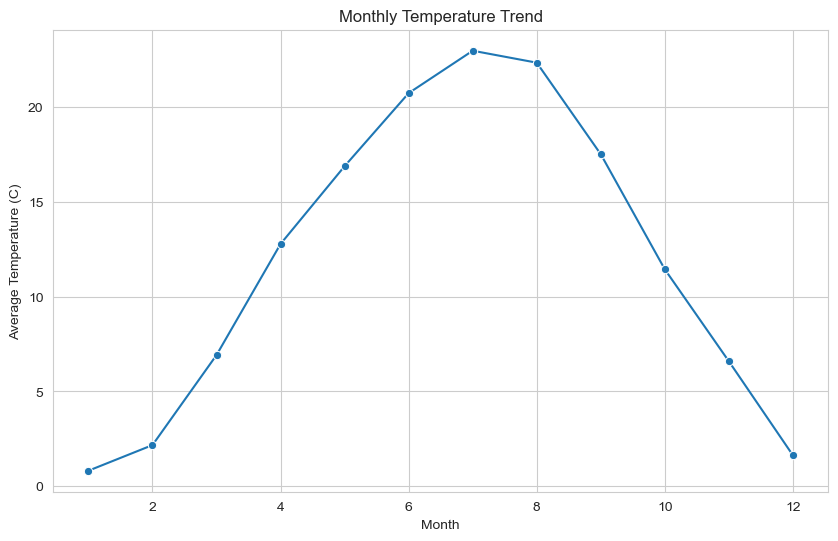

In [15]:
plt.figure(figsize=(10,6))
sns.lineplot(
    x=monthly_temp.index,
    y=monthly_temp.values,
    marker="o"
)
plt.title("Monthly Temperature Trend")
plt.xlabel("Month")
plt.ylabel("Average Temperature (C)")
plt.show()

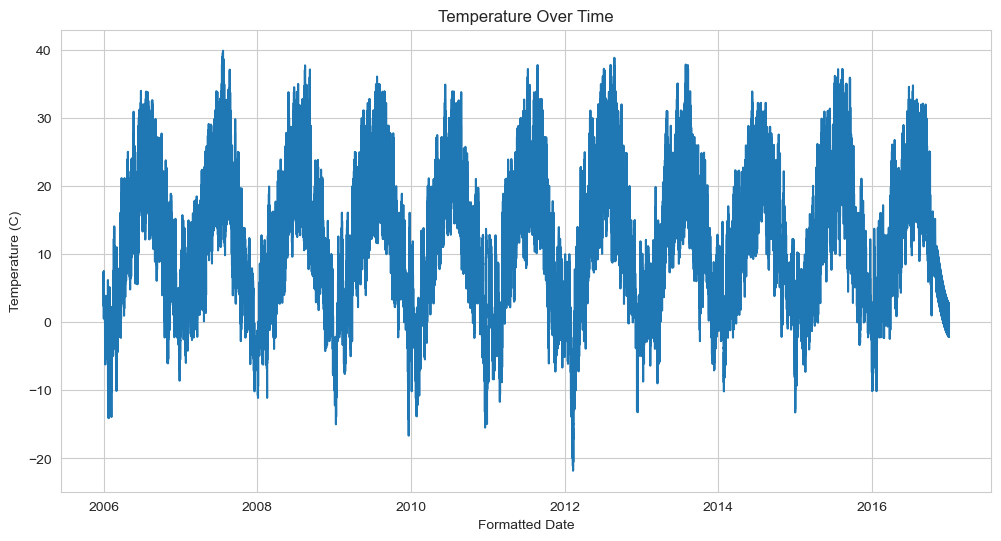

In [16]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=df,
    x="Formatted Date",
    y="Temperature (C)"
)
plt.title("Temperature Over Time")
plt.show()

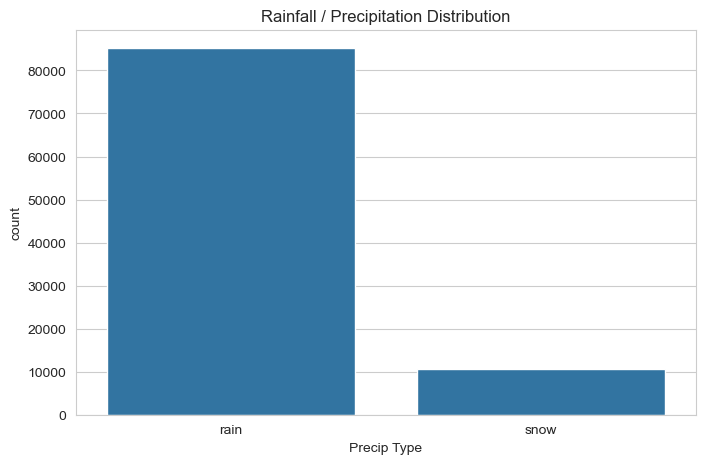

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(
    x="Precip Type",
    data=df
)
plt.title("Rainfall / Precipitation Distribution")
plt.show()

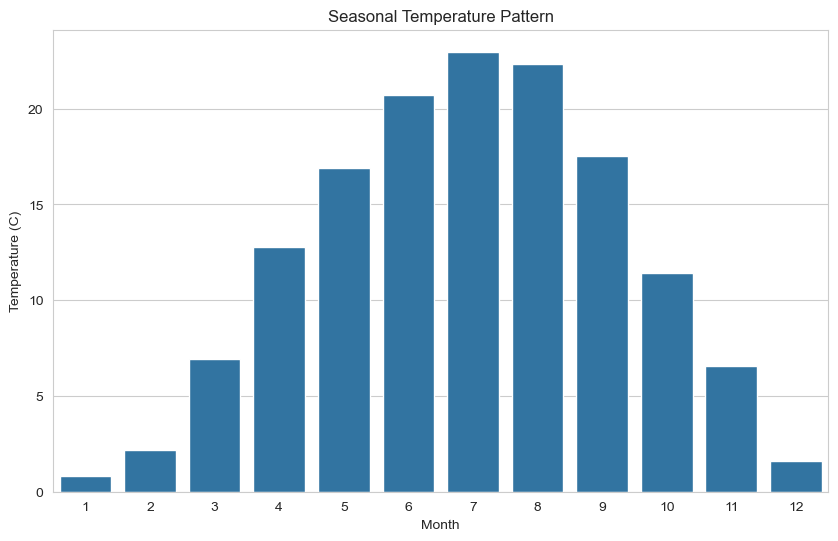

In [18]:
seasonal_temp = df.groupby("Month")["Temperature (C)"].mean()
plt.figure(figsize=(10,6))
sns.barplot(
    x=seasonal_temp.index,
    y=seasonal_temp.values
)
plt.title("Seasonal Temperature Pattern")
plt.xlabel("Month")
plt.ylabel("Temperature (C)")
plt.show()

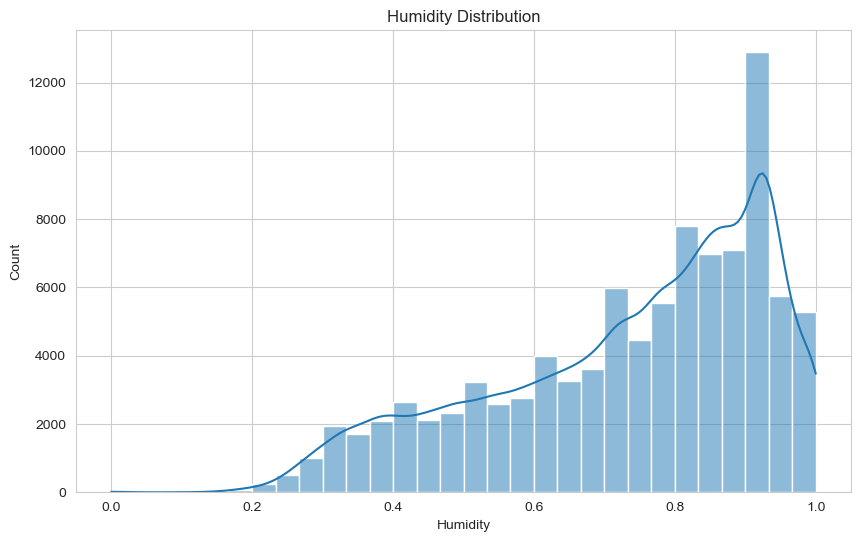

In [19]:
plt.figure(figsize=(10,6))
sns.histplot(
    df["Humidity"],
    bins=30,
    kde=True
)
plt.title("Humidity Distribution")
plt.show()

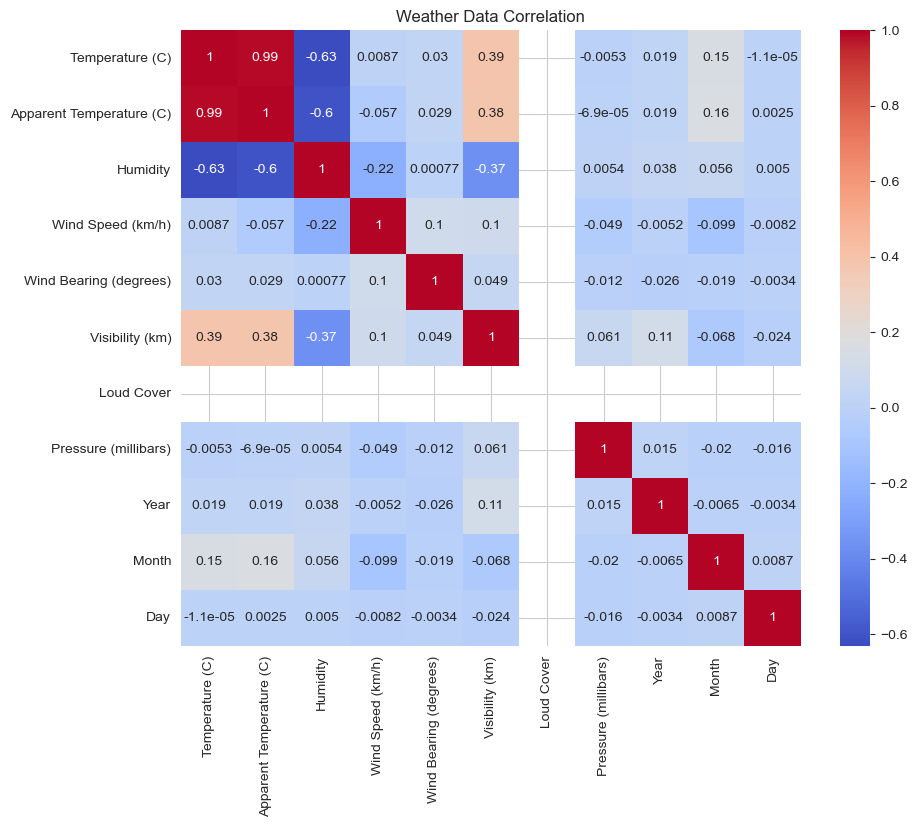

In [20]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("Weather Data Correlation")
plt.show()

In [21]:
print("WEATHER DATA INSIGHTS")
print("----------------------")
max_temp = df["Temperature (C)"].max()
min_temp = df["Temperature (C)"].min()
print("Maximum Temperature:", max_temp)
print("Minimum Temperature:", min_temp)
warmest_month = seasonal_temp.idxmax()
print("Warmest Month:", warmest_month)

WEATHER DATA INSIGHTS
----------------------
Maximum Temperature: 39.90555555555555
Minimum Temperature: -21.822222222222223
Warmest Month: 7
